### 1) Bonds & Yields

A bond is a financial instrument representing a loan made by an investor to a borrower, typically a government or corporation, in exchange for interest payments and the return of principal at maturity. Bonds are issued in primary markets, where the issuer raises capital by selling debt securities to investors, often through auctions for governments or underwriting by investment banks for corporates issuances. 

There is an inverse relationship between bond prices and interest rates: when market interest rates rise, existing bonds with lower coupons become less attractive, causing their prices to fall; conversely, when interest rates decline, existing bonds with higher coupons increase in value (Compatible with Law of One Price and No Arbitrage Conditions)


### 2) Euro area yield curves

 Below we see the AAA rated bonds yield curve for March 16th 2026. What we see is a typical yield curve for developed markets, with and upward sloping shape, implying an yield premium that increases with time. This reflects both expectations of stable or slightly rising future interest rates and the presence of a positive term premium, as investors demand compensation for holding longer-term bonds. 
 
 Moreover, longer maturities are exposed to greater duration risk, making them more sensitive to interest rate changes. 

In [1]:
import matplotlib.pyplot as plt
import pandas as pd 

In [2]:
# ref: Mar 16th 2026 

yield_0 = 2.088 
yield_1 = 2.227 
yield_2 = 2.298 
yield_3 = 2.340 
yield_4 = 2.372 
yield_5 = 2.403 
yield_6 = 2.436 
yield_7 = 2.473 
yield_8 = 2.513 
yield_9 = 2.555

### 3) Definition of a spot rate

A spot rate is the yield on a zero-coupon bond for a given maturity, representing the return an investor earns from investing today until that maturity with no intermediate cash flows. Each maturity has its own spot rate, forming the term structure of interest rates.

**Characteristics of spot rates**:
* Zero-coupon basis: Spot rates correspond to bonds with a single payment at maturity.
* Term-dependent: Each maturity has a distinct rate (e.g., 6M, 1Y, 5Y).
* No reinvestment risk: Since there are no intermediate coupons.
* Fundamental for pricing: All fixed-income securities can be priced as discounted cash flows using spot rates.

#### Bootstrapping: Forward rates cen be derived from spot rates

Spot rates are not directly observable for all maturities and must be extracted from traded bond prices using bootstrapping:

Spot rate from zero-coupon bonds

To derive spot rates from zero-coupon bonds, the following relationship is used:

$$
y = m \left[ \left( \frac{M}{P} \right)^{\frac{1}{m \cdot n}} - 1 \right]
$$

Where:

* $y$ = spot rate
* $P$ = present value (price) of the zero-coupon bond
* $M$ = par value of the bond 
* $n$ = number of years to maturity
* $m$ = number of compounding periods per year
This recursive process constructs the full spot yield curve.

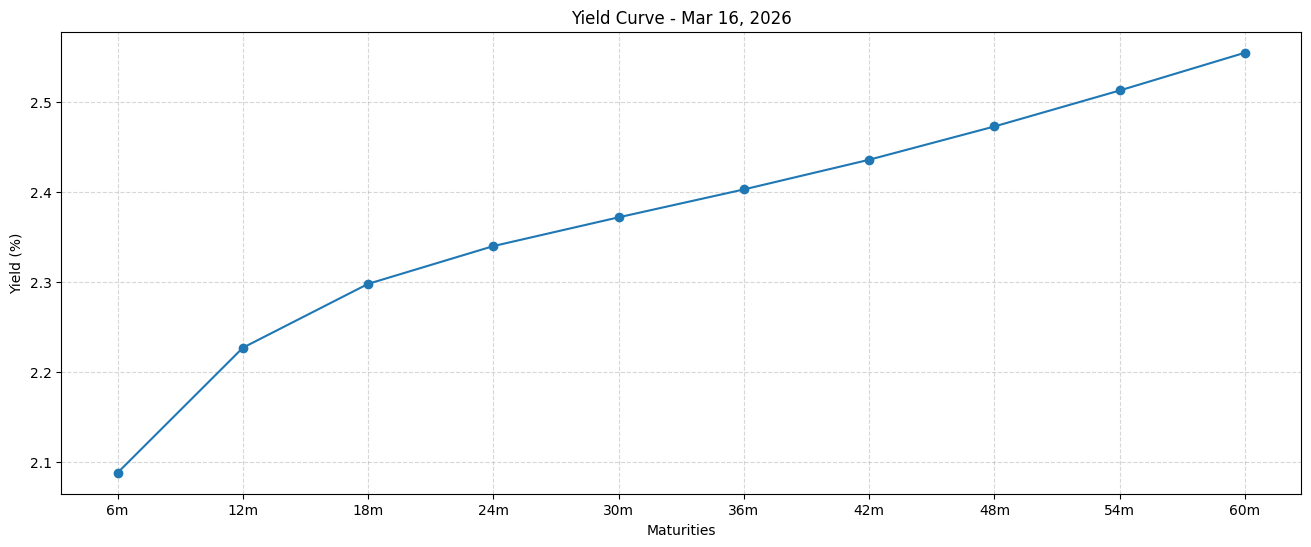

In [3]:
yields = [globals()[f"yield_{i}"] for i in range(10)]
x = [f"{(i+1)*6}m" for i in range(10)]

plt.figure(figsize=(16,6))
plt.plot(x, yields, marker='o')
plt.xlabel("Maturities")
plt.ylabel("Yield (%)")
plt.grid(linestyle="--", alpha=0.5)
plt.title("Yield Curve - Mar 16, 2026")
plt.grid(True)
plt.show()

### 4) Linear Interpolation

Linear interpolation estimates an unknown value by assuming a straight-line relationship between two known data points. It effectively computes a weighted average based on the relative position of the unknown point between them.

The interpolated value is given by:

$$
y_i = y_1 + (y_2 - y_1) \cdot \frac{x_i - x_1}{x_2 - x_1}
$$

#### **Where:**

* $x_1$ = lower point on the x-axis (lower maturity)
* $x_2$ = higher point on the x-axis (higher maturity)
* $x_i$ = point to be interpolated (target maturity)
* $y_1$ = yield corresponding to $x_1$
* $y_2$ = yield corresponding to $x_2$
* $y_i$ = interpolated yield

In [4]:
### estimating 12m (yield_1) yield based on 6m and 18m

yi = yield_0 + (yield_2 - yield_0) * ((12-6)/(18-6))

print("Interpolated value for 12m yield:", yi)
print("Actual value for 12m yield:", yield_1)
print("Pricing error:", (yi - yield_1))
print("Relative pricing error:", (yi - yield_1)/yield_1)
print("Comment: I intentionally chose the curviest section of the curve to show how linear interpolation can be imprecise depending on where we apply it.")

Interpolated value for 12m yield: 2.193
Actual value for 12m yield: 2.227
Pricing error: -0.03399999999999981
Relative pricing error: -0.015267175572518998
Comment: I intentionally chose the curviest section of the curve to show how linear interpolation can be imprecise depending on where we apply it.


In [5]:
### estimating 30m (yield_5) yield based on 24m and 36m

yi2 = yield_4 + (yield_6 - yield_4) * ((30-24)/(36-24))

print("Interpolated value for 12m yield:", yi2)
print("Actual value for 12m yield:", yield_5)
print("Pricing error:", (yi2 - yield_5))
print("Relative pricing error:", (yi2 - yield_5)/yield_5)
print("Comment: Now i chose a flatter section of the curve where linear interpolation can be more precise.")

Interpolated value for 12m yield: 2.404
Actual value for 12m yield: 2.403
Pricing error: 0.0009999999999998899
Relative pricing error: 0.00041614648356216806
Comment: Now i chose a flatter section of the curve where linear interpolation can be more precise.


### 5) Calculating STRIPS from yields

Considering these are zero-coupon bonds, $m = 1$. Expressing the formula in terms of $P$, we obtain:

$$
P = \frac{M}{(1 + y)^{n}}
$$

The results show that all STRIP prices are below their issuance value (par = 100). This is expected, as zero-coupon bonds are discounted at positive spot rates, meaning their present value must be lower than the future payment at maturity. Additionally, the longer the maturity, the lower the price, reflecting the fact that cash flows are discounted over a longer horizon. Longer-term bonds are also more sensitive to changes in interest rates, which is captured by duration. This implies that price fluctuations are larger for longer maturities, even if long-term yields themselves may be relatively less volatile.

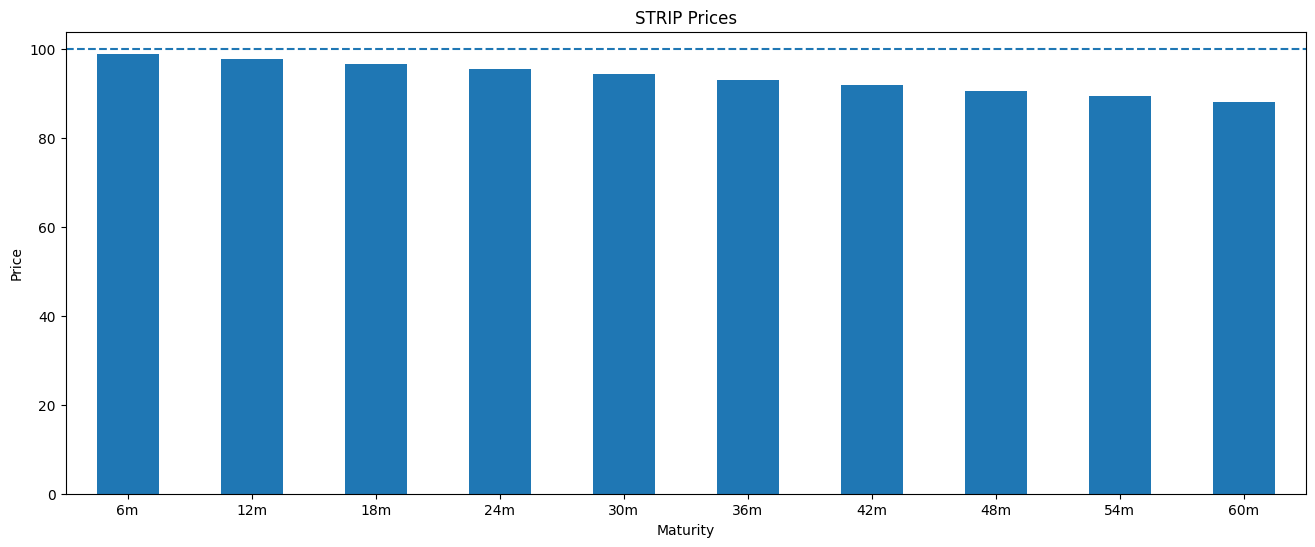

In [6]:
P =[]
mat = [((i+1)*6)/12 for i in range(10)]
M = 100

for y, i in zip(yields, mat):
    
        p = M / ((y/100 + 1)**i)
        P.append(p)

P = pd.DataFrame(P, columns=['Price'], index=x)


P.plot(kind="bar", legend=False,figsize=(16,6))
plt.axhline(y=100, linestyle='--')
plt.xlabel("Maturity")
plt.ylabel("Price")
plt.xticks(rotation=0)
plt.title("STRIP Prices")
plt.show()

### 6) Forward rates

A forward rate is the interest rate agreed today for a loan or investment that will begin at a specified date in the future and end at a later date. It represents the implied future interest rate embedded in the current term structure of spot rates.

**Characteristics of forward rates**

- Forward rates are not directly observable in the market; they are implied by spot rates.  
- They are derived under the no-arbitrage condition.  
- They represent the rate that equates:
  - investing for a longer maturity, and  
  - investing short-term and reinvesting at the forward rate.  

 **Derivation of forward rates**

Forward rates are obtained from spot rates using the no-arbitrage condition:

$$
(1+s_{t_2})^{t_2} = (1+s_{t_1})^{t_1}(1+f_{t_1,t_2})^{t_2-t_1}
$$

Solving for the forward rate:

$$
f_{t_1,t_2} = \left( \frac{(1+s_{t_2})^{t_2}}{(1+s_{t_1})^{t_1}} \right)^{\frac{1}{t_2-t_1}} - 1
$$

In [7]:
#updating names
spot_rates = yields

maturities = mat

#expressing in p.p.
spot_rates_dec = [s / 100 for s in spot_rates]

forward_rates = []
forward_labels = []

for i in range(1, len(maturities)):
    t1 = maturities[i-1]
    t2 = maturities[i]
    s1 = spot_rates_dec[i-1]
    s2 = spot_rates_dec[i]
    
    f = ((1 + s2)**t2 / (1 + s1)**t1)**(1 / (t2 - t1)) - 1
    forward_rates.append(f * 100)  
    forward_labels.append(f"{t1:.1f}Y → {t2:.1f}Y")

forward_df = pd.DataFrame({
    "Interval": forward_labels,
    "Forward Rate (%)": forward_rates
})

forward_df

,Interval,Forward Rate (%)
0,0.5Y → 1.0Y,2.366189
1,1.0Y → 1.5Y,2.440148
2,1.5Y → 2.0Y,2.466103
3,2.0Y → 2.5Y,2.500100
4,2.5Y → 3.0Y,2.558141
5,3.0Y → 3.5Y,2.634223
6,3.5Y → 4.0Y,2.732374
7,4.0Y → 4.5Y,2.833563
8,4.5Y → 5.0Y,2.933775


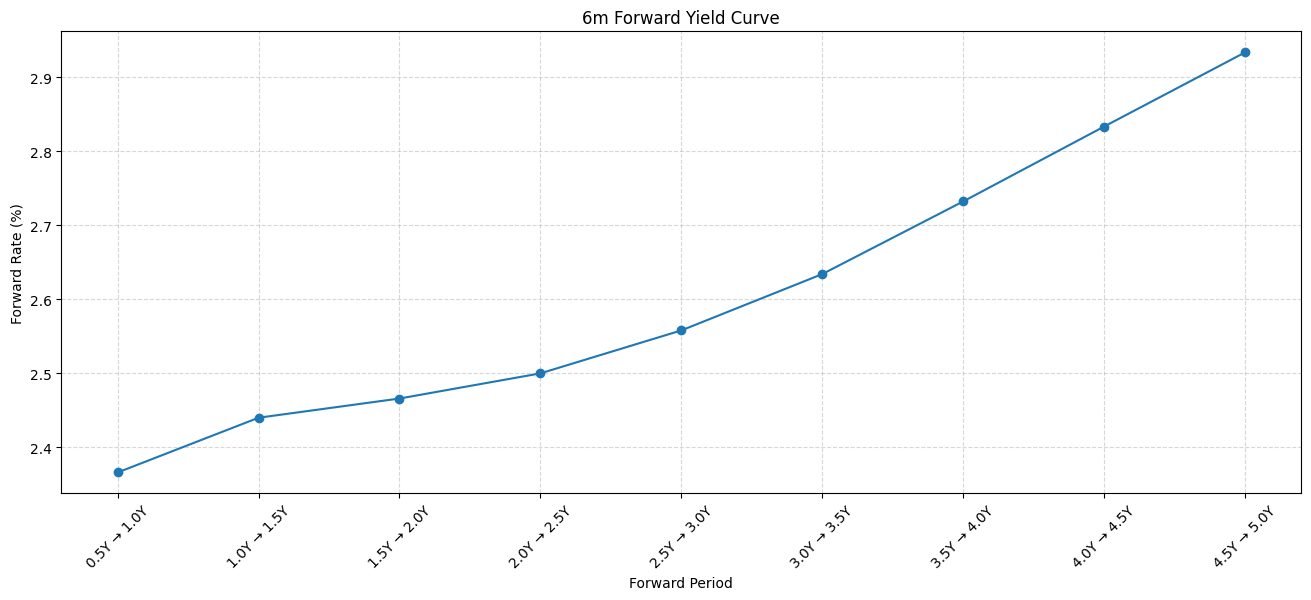

In [8]:
plt.figure(figsize=(16,6))
plt.plot(forward_labels, forward_rates, marker='o')
plt.xlabel("Forward Period")
plt.ylabel("Forward Rate (%)")
plt.title("6m Forward Yield Curve")
plt.grid(linestyle="--", alpha=0.5)
plt.xticks(rotation=45)
plt.show()

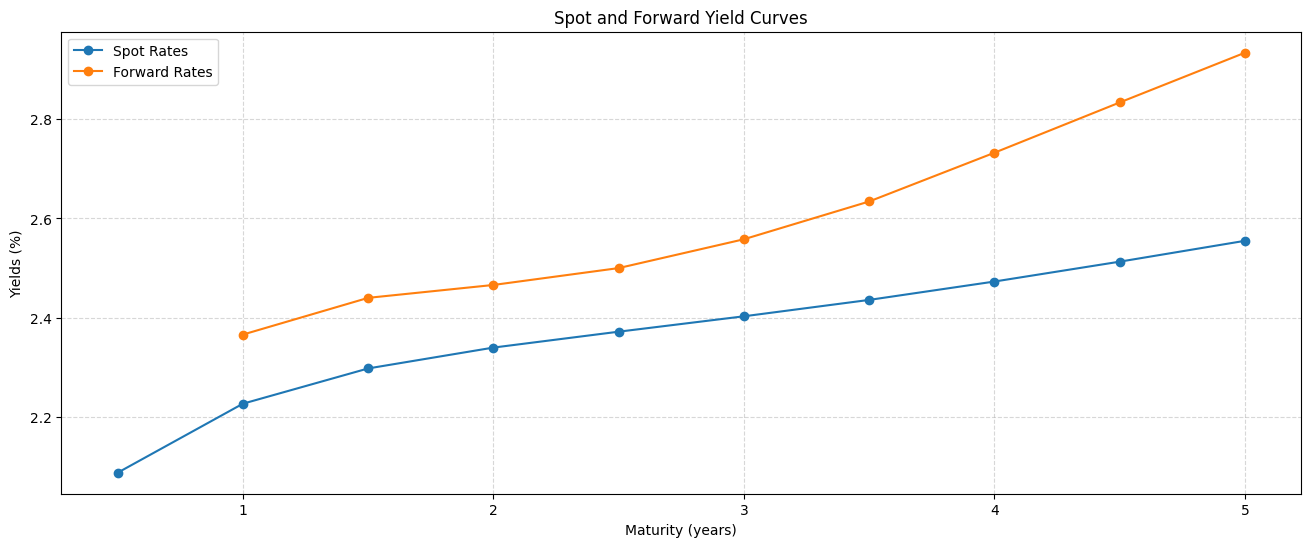

In [9]:
# Spot curve
spot_labels = mat

# Forward curve positioned at the second maturity of each interval
forward_x = mat[1:]

plt.figure(figsize=(16,6))
plt.plot(maturities, spot_rates, marker='o', label='Spot Rates')
plt.plot(forward_x, forward_rates, marker='o', label='Forward Rates')
plt.xlabel("Maturity (years)")
plt.ylabel("Yields (%)")
plt.title("Spot and Forward Yield Curves")
plt.legend()
plt.grid(linestyle="--", alpha=0.5)
plt.show()

### 7) 3-year French government bond pricing

We consider a 3-year French government bond issued on January 1st 2025, with par value equal to 1000, annual coupon rate equal to 2%, and semiannual coupon payments. The coupon paid every six months is therefore equal to 10, and the final payment at maturity is equal to 1010.

Let $CF_t$ denote the cash flow paid at time $t$, and let $s_t$ denote the spot rate for maturity $t$. The bond price obtained from the spot curve is:

$$
P_0 = \sum_{t \in \{0.5,1,1.5,2,2.5,3\}} \frac{CF_t}{(1+s_t)^t}
$$

Using forward rates, the same price can be recovered through cumulative discounting under the no-arbitrage condition. If $f_{i-1,i}$ is the 6-month forward rate between two consecutive cash-flow dates, then:

$$
P_0 = \sum_{i=1}^{6} CF_{t_i} \prod_{j=1}^{i} (1+f_{j-1,j})^{-0.5}
$$

In the first interval, the initial 6-month investment is discounted with the 6-month spot rate.

In [10]:
import numpy as np
from scipy.optimize import brentq

issue_date = pd.Timestamp('2025-01-01')
par_value = 1000
coupon_rate = 0.02
coupon_per_period = par_value * coupon_rate / 2
payment_frequency = 2

bond_maturities = maturities[:6]
spot_rates_3y = np.array(spot_rates[:6]) / 100
forward_rates_3y = np.array([spot_rates[0]] + forward_rates[:5]) / 100
cash_flows = np.array([coupon_per_period] * 5 + [coupon_per_period + par_value])

spot_discount_factors = 1 / (1 + spot_rates_3y) ** np.array(bond_maturities)
price_spot = np.sum(cash_flows * spot_discount_factors)

forward_discount_factors = []
for n in range(1, len(bond_maturities) + 1):
    discount_factor = 1
    for f in forward_rates_3y[:n]:
        discount_factor *= (1 + f) ** (-0.5)
    forward_discount_factors.append(discount_factor)

forward_discount_factors = np.array(forward_discount_factors)
price_forward = np.sum(cash_flows * forward_discount_factors)

pricing_df = pd.DataFrame({
    'Maturity (years)': bond_maturities,
    'Cash Flow': cash_flows,
    'Spot Rate (%)': np.array(spot_rates[:6]),
    'Spot DF': spot_discount_factors,
    'Forward-implied DF': forward_discount_factors
})

print('Bond price using spot rates:', round(price_spot, 4))
print('Bond price using forward rates:', round(price_forward, 4))
print('Difference:', round(price_spot - price_forward, 10))

pricing_df

Bond price using spot rates: 988.8761
Bond price using forward rates: 988.8761
Difference: 0.0


,Maturity (years),Cash Flow,Spot Rate (%),Spot DF,Forward-implied DF
0,0.5,10.0,2.088,0.989721,0.989721
1,1.0,10.0,2.227,0.978215,0.978215
2,1.5,10.0,2.298,0.966494,0.966494
3,2.0,10.0,2.340,0.954793,0.954793
4,2.5,10.0,2.372,0.943077,0.943077
5,3.0,1010.0,2.403,0.931241,0.931241


The two prices are identical up to rounding error. This is the expected result, since spot rates and forward rates are linked by no-arbitrage and therefore imply the same discount factors for the bond cash flows.

### 8) Dirty and clean price 50 days after issuance

We now assume that the bond is purchased 50 days after issuance. The dirty price is the full transaction price, including accrued interest, while the clean price excludes accrued interest:

$$
\text{Dirty Price} = \text{Clean Price} + \text{Accrued Interest}
$$

For accrued interest, we use a simple Actual/Actual convention within the first coupon period. Since the first coupon runs from January 1st 2025 to July 1st 2025, the accrued coupon after 50 days is computed as the fraction of the 10 coupon earned over that period.

To obtain the dirty price at the purchase date, the remaining cash flows are discounted from the issue date with spot rates and then carried forward to settlement using the short-end spot discount factor.

In [11]:
settlement_date = issue_date + pd.Timedelta(days=50)
days_elapsed = (settlement_date - issue_date).days
first_coupon_date = pd.Timestamp('2025-07-01')
days_in_coupon_period = (first_coupon_date - issue_date).days
settlement_time = days_elapsed / 365

accrued_interest = coupon_per_period * days_elapsed / days_in_coupon_period
settlement_discount_factor = 1 / (1 + spot_rates_3y[0]) ** settlement_time

dirty_price = np.sum(cash_flows * spot_discount_factors / settlement_discount_factor)
clean_price = dirty_price - accrued_interest

price_50d_df = pd.DataFrame({
    'Measure': ['Accrued interest', 'Dirty price', 'Clean price'],
    'Value': [accrued_interest, dirty_price, clean_price]
})

price_50d_df['Value'] = price_50d_df['Value'].round(4)
price_50d_df

,Measure,Value
0,Accrued interest,2.7624
1,Dirty price,991.6794
2,Clean price,988.9170


### 9) Yield to maturity

The yield to maturity (YTM) is the single discount rate that makes the present value of all promised cash flows equal to the observed bond price. With semiannual compounding, the YTM $y$ solves:

$$
P_0 = \sum_{i=1}^{6} \frac{CF_i}{\left(1+\frac{y}{2}\right)^i}
$$

The YTM is therefore an internal rate of return for the bond if it is held until maturity and all coupons are reinvested at that same rate. In general, if the bond price is above par, the YTM is below the coupon rate, whereas if the bond price is below par, the YTM is above the coupon rate.

In [12]:
def bond_price_from_ytm(ytm, cash_flows=cash_flows):
    periods = np.arange(1, len(cash_flows) + 1)
    return np.sum(cash_flows / (1 + ytm / 2) ** periods)

ytm = brentq(lambda y: bond_price_from_ytm(y) - price_spot, 0.0, 0.10)

ytm_df = pd.DataFrame({
    'Measure': ['Bond price', 'Annual coupon rate (%)', 'YTM (%)'],
    'Value': [price_spot, coupon_rate * 100, ytm * 100]
})

ytm_df['Value'] = ytm_df['Value'].round(4)
ytm_df

,Measure,Value
0,Bond price,988.8761
1,Annual coupon rate (%),2.0000
2,YTM (%),2.3864


### 10) DV01, duration, convexity

DV01 measures the price sensitivity of the bond to a one-basis-point variation in yield. For the requested 5 basis point decrease in YTM, we first compute the corresponding price change and then relate it to the standard DV01 interpretation.

For duration and convexity, we use effective measures based on a symmetric repricing of the bond for an increase and a decrease of 0.55% in YTM. Denoting the initial price by $P_0$, the price after a downward shift by $P_{-}$, the price after an upward shift by $P_{+}$, and the yield shock by $\Delta y$, we obtain:

$$
D_{\mathrm{eff}} = \frac{P_{-} - P_{+}}{2P_0\Delta y}
$$

$$
C_{\mathrm{eff}} = \frac{P_{-} + P_{+} - 2P_0}{P_0(\Delta y)^2}
$$

Using duration and convexity, the price variation for a yield change $\Delta y$ can be approximated by:

$$
\frac{\Delta P}{P_0} \approx -D_{\mathrm{eff}}\Delta y + \frac{1}{2}C_{\mathrm{eff}}(\Delta y)^2
$$

A rise in yields should reduce the bond price, while a fall in yields should increase it. Convexity improves the approximation by capturing the curvature of the price-yield relationship.

In [13]:
base_price = bond_price_from_ytm(ytm)

price_minus_5bp = bond_price_from_ytm(ytm - 0.0005)
price_minus_1bp = bond_price_from_ytm(ytm - 0.0001)
price_plus_1bp = bond_price_from_ytm(ytm + 0.0001)

price_change_5bp = price_minus_5bp - base_price
dv01 = (price_minus_1bp - price_plus_1bp) / 2

delta_y = 0.0055
price_down = bond_price_from_ytm(ytm - delta_y)
price_up = bond_price_from_ytm(ytm + delta_y)

effective_duration = (price_down - price_up) / (2 * base_price * delta_y)
effective_convexity = (price_down + price_up - 2 * base_price) / (base_price * delta_y ** 2)

risk_df = pd.DataFrame({
    'Measure': [
        'Price change for -5 bps',
        'DV01',
        'Effective duration',
        'Effective convexity'
    ],
    'Value': [price_change_5bp, dv01, effective_duration, effective_convexity]
})

risk_df['Value'] = risk_df['Value'].round(6)
risk_df

,Measure,Value
0,Price change for -5 bps,1.431000
1,DV01,0.285955
2,Effective duration,2.891911
3,Effective convexity,9.918696


The positive DV01 confirms that a decrease in YTM raises the bond price. The duration is positive, which reflects the inverse relationship between yields and prices, while the positive convexity shows that the price-yield curve is curved rather than linear.

We now apply the duration-convexity approximation to a larger yield shock of 1.8% in absolute value and compare it with the exact repriced bond value.

In [14]:
shock_levels = [0.018, -0.018]
shock_labels = ['+1.8% YTM shock', '-1.8% YTM shock']
rows = []

for label, shock in zip(shock_labels, shock_levels):
    approx_change = base_price * (-effective_duration * shock + 0.5 * effective_convexity * shock ** 2)
    approx_price = base_price + approx_change
    exact_price = bond_price_from_ytm(ytm + shock)
    rows.append([
        label,
        shock * 100,
        approx_change,
        approx_price,
        exact_price
    ])

shock_df = pd.DataFrame(rows, columns=[
    'Scenario',
    'Yield change (%)',
    'Approx. price change',
    'Approx. price',
    'Exact repriced bond'
])

shock_df = shock_df.round(4)
shock_df

,Scenario,Yield change (%),Approx. price change,Approx. price,Exact repriced bond
0,+1.8% YTM shock,1.8,-49.8864,938.9897,938.9564
1,-1.8% YTM shock,-1.8,53.0643,1041.9404,1041.9752


For the positive yield shock, the approximation gives a lower bond price, while for the negative yield shock it gives a higher bond price. This is consistent with standard bond pricing intuition. The approximated values remain very close to the exact repriced values, showing that duration and convexity provide a good local approximation even for a relatively large yield movement.